<a href="https://colab.research.google.com/github/MarkNoble-1/portfolio/blob/main/Recell_Supervised_Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Learning - Foundations Project: ReCell

## Problem Statement

### Business Context

Buying and selling used phones and tablets used to be something that happened on a handful of online marketplace sites. But the used and refurbished device market has grown considerably over the past decade, and a new IDC (International Data Corporation) forecast predicts that the used phone market would be worth \\$52.7bn by 2023 with a compound annual growth rate (CAGR) of 13.6% from 2018 to 2023. This growth can be attributed to an uptick in demand for used phones and tablets that offer considerable savings compared with new models.

Refurbished and used devices continue to provide cost-effective alternatives to both consumers and businesses that are looking to save money when purchasing one. There are plenty of other benefits associated with the used device market. Used and refurbished devices can be sold with warranties and can also be insured with proof of purchase. Third-party vendors/platforms, such as Verizon, Amazon, etc., provide attractive offers to customers for refurbished devices. Maximizing the longevity of devices through second-hand trade also reduces their environmental impact and helps in recycling and reducing waste. The impact of the COVID-19 outbreak may further boost this segment as consumers cut back on discretionary spending and buy phones and tablets only for immediate needs.


### Objective

The rising potential of this comparatively under-the-radar market fuels the need for an ML-based solution to develop a dynamic pricing strategy for used and refurbished devices. ReCell, a startup aiming to tap the potential in this market, has hired you as a data scientist. They want you to analyze the data provided and build a linear regression model to predict the price of a used phone/tablet and identify factors that significantly influence it.


### Data Description

The data contains the different attributes of used/refurbished phones and tablets. The data was collected in the year 2021. The detailed data dictionary is given below.


- brand_name: Name of manufacturing brand
- os: OS on which the device runs
- screen_size: Size of the screen in cm
- 4g: Whether 4G is available or not
- 5g: Whether 5G is available or not
- main_camera_mp: Resolution of the rear camera in megapixels
- selfie_camera_mp: Resolution of the front camera in megapixels
- int_memory: Amount of internal memory (ROM) in GB
- ram: Amount of RAM in GB
- battery: Energy capacity of the device battery in mAh
- weight: Weight of the device in grams
- release_year: Year when the device model was released
- days_used: Number of days the used/refurbished device has been used
- normalized_new_price: Normalized price of a new device of the same model in euros
- normalized_used_price: Normalized price of the used/refurbished device in euros

## Importing necessary libraries

In [ ]:
!pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 -q --user

In [ ]:

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model using statsmodels
import statsmodels.api as sm

# to build linear regression model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# to compute VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
UDD = pd.read_csv('/content/drive/MyDrive/Data Science and Business Analytics/Supervised Learning - Foundations/used_device_data.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Overview

- Observations
- Sanity checks

###First and Last 5 rows of the dataset

In [ ]:
UDD.head() #first 5 rows of the dataset

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,2020,127,4.307572,4.715100
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,2020,325,5.162097,5.519018
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,2020,162,5.111084,5.884631
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,2020,345,5.135387,5.630961
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,2020,293,4.389995,4.947837


In [ ]:
UDD.tail() #last 5 rows of the dataset

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
3449,Asus,Android,15.34,yes,no,NaN,8.0,64.0,6.0,5000.0,190.0,2019,232,4.492337,6.483872
3450,Asus,Android,15.24,yes,no,13.0,8.0,128.0,8.0,4000.0,200.0,2018,541,5.037732,6.251538
3451,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,3.0,4000.0,165.0,2020,201,4.357350,4.528829
3452,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,2.0,4000.0,160.0,2020,149,4.349762,4.624188
3453,Alcatel,Android,12.83,yes,no,13.0,5.0,16.0,2.0,4000.0,168.0,2020,176,4.132122,4.279994


Observations:

- The data looks as expected

### Shape of the dataset

In [ ]:
UDD.shape #shape of the data

(3454, 15)

Observations:

- there are 3454 rows and 15 columns in the dataset

### Statistical summary of the data

In [ ]:
UDD.describe(include=[np.number]) #statistical summary of the numerical data

,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
count,3454.000000,3275.000000,3452.000000,3450.000000,3450.000000,3448.000000,3447.000000,3454.000000,3454.000000,3454.000000,3454.000000
mean,13.713115,9.460208,6.554229,54.573099,4.036122,3133.402697,182.751871,2015.965258,674.869716,4.364712,5.233107
std,3.805280,4.815461,6.970372,84.972371,1.365105,1299.682844,88.413228,2.298455,248.580166,0.588914,0.683637
min,5.080000,0.080000,0.000000,0.010000,0.020000,500.000000,69.000000,2013.000000,91.000000,1.536867,2.901422
25%,12.700000,5.000000,2.000000,16.000000,4.000000,2100.000000,142.000000,2014.000000,533.500000,4.033931,4.790342
50%,12.830000,8.000000,5.000000,32.000000,4.000000,3000.000000,160.000000,2015.500000,690.500000,4.405133,5.245892
75%,15.340000,13.000000,8.000000,64.000000,4.000000,4000.000000,185.000000,2018.000000,868.750000,4.755700,5.673718
max,30.710000,48.000000,32.000000,1024.000000,12.000000,9720.000000,855.000000,2020.000000,1094.000000,6.619433,7.847841


In [ ]:
UDD.describe(include=[object]) #statistical summary of the categorical data

,brand_name,os,4g,5g
count,3454,3454,3454,3454
unique,34,4,2,2
top,Others,Android,yes,no
freq,502,3214,2335,3302


Observations:
- Based on the count, there seems to be missing data for some numerical columns
- release_year would make more sense as a categorical variable
- We will be comparing 43 unique brands with only 4 different types of OS

### Datatype Information & Missing Data

In [ ]:
UDD.duplicated().sum() #checking for duplicates

np.int64(0)

In [ ]:
UDD.info() #datatype information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

In [ ]:
UDD.isnull().sum() #missing data

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


Observations:

- there is no duplicated data in the dataset

- The datatypes are as expected, implying that there is no missing data in numeric columns

- The following columns contain missing data:
 -  5   main_camera_mp: 179 missing         
 - 6   selfie_camera_mp: 2 missing       
 - 7   int_memory:       4 missing   
 - 8   ram:              4 missing     
 -  9   battery:         6 missing     
 - 10  weight            7 missing    

## Exploratory Data Analysis (EDA)

In [ ]:
udd_with_missing_values = UDD.copy() #making a copy of the dataset

### What does the distribution of normalized used device prices look like?

array([[<Axes: title={'center': 'normalized_used_price'}>]], dtype=object)

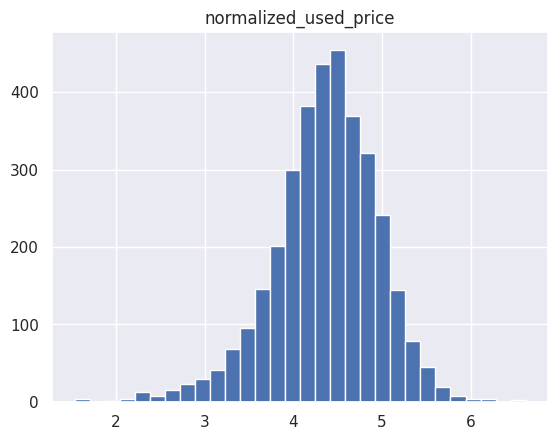

In [ ]:
udd_with_missing_values.hist(column='normalized_used_price', bins=30)

array([[<Axes: title={'center': 'normalized_new_price'}>]], dtype=object)

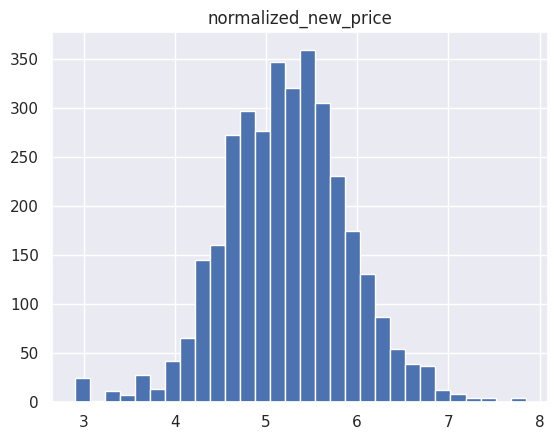

In [ ]:
udd_with_missing_values.hist(column='normalized_new_price', bins=30)

Observations:

- the distribution of normalized used prices is approximately normal with a slight left skew
- the distribution of normalized new prices is approximately normal with a slight right skew

### What percentage of the used device market is dominated by Android devices?

<Axes: xlabel='os', ylabel='count'>

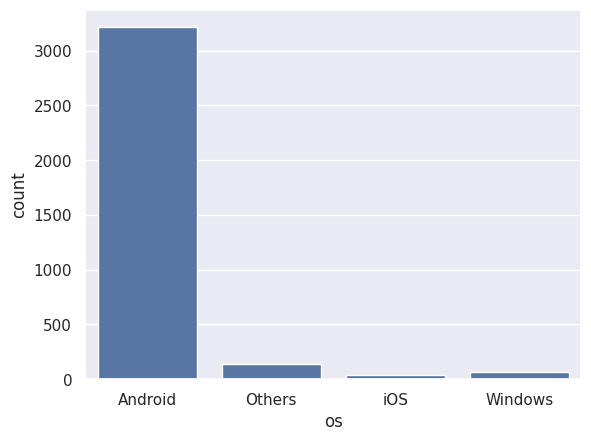

In [ ]:
sns.countplot(x=udd_with_missing_values['os'])

In [ ]:
Android_count = udd_with_missing_values['os'].value_counts()['Android'] #count of Android devices in the dataset
Total_count = udd_with_missing_values['os'].value_counts().sum()        #total count of devices in the dataset
Android_domination = (Android_count/Total_count)*100                    #percentage of Android devices in the dataset
print(f'The percentage of the used device market that is dominated by Android devices is {Android_domination:.2f}%')

The percentage of the used device market that is dominated by Android devices is 93.05%


Observations:

- The percentage of the used device market that is dominated by Android devices is 93.05%

### How does the amount of RAM vary with the brand?

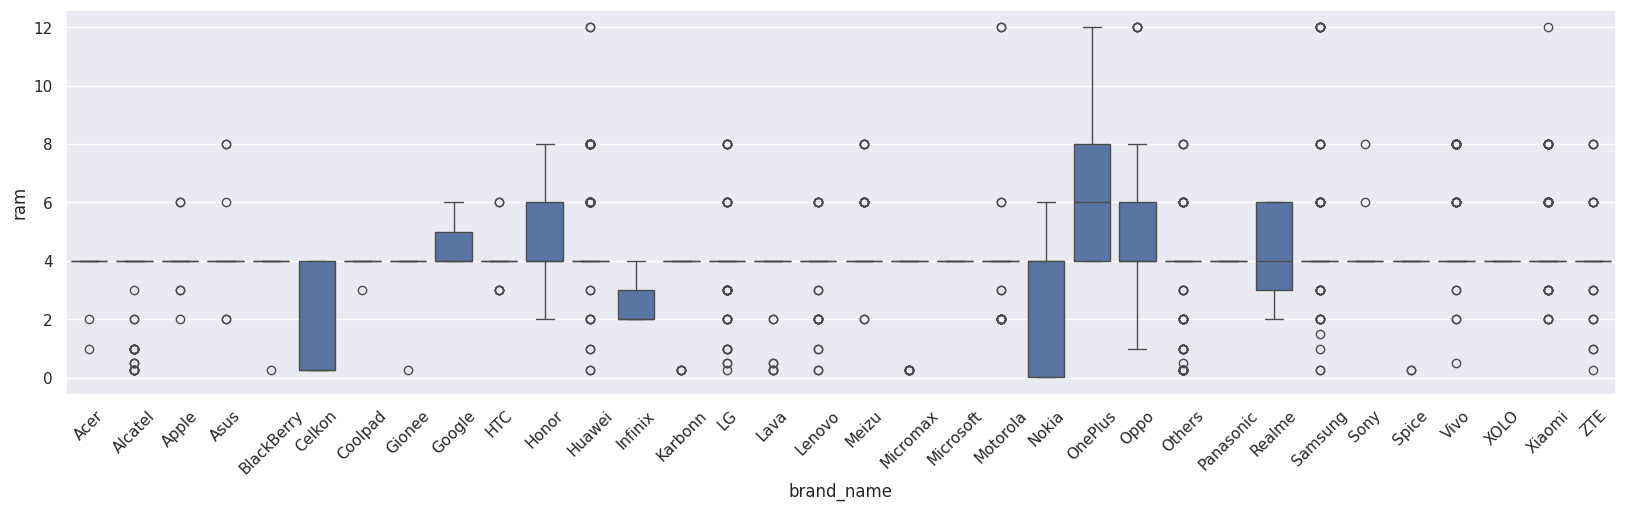

In [ ]:
brand_name_alphabetized = sorted(udd_with_missing_values['brand_name'].unique()) #list of unique brands in alphabetical order
plt.figure(figsize=(20,5))
sns.boxplot(x=udd_with_missing_values['brand_name'], y=udd_with_missing_values['ram'], order = brand_name_alphabetized) # box plot of ram by brand
plt.xticks(rotation=45)
plt.show()

Observations:

- there are many outliers in the RAM offered by each brand
- all brands offer at least 4gb of RAM on one or more of the devices they sell
- 75% OnePlus devices have between 4 and 8 gb of RAM and 25% have between 8 and 12 gb of RAM, suggesting that OnePlus devices offer more RAM on average than other devices

### How does the weight vary for phones and tablets offering large batteries (more than 4500 mAh)?

In [ ]:
threshold = 4500
large_battery_devices = udd_with_missing_values[(udd_with_missing_values['battery'] > threshold)]  #filter for devices with large batteries

In [ ]:
large_battery_devices.shape

(341, 15)

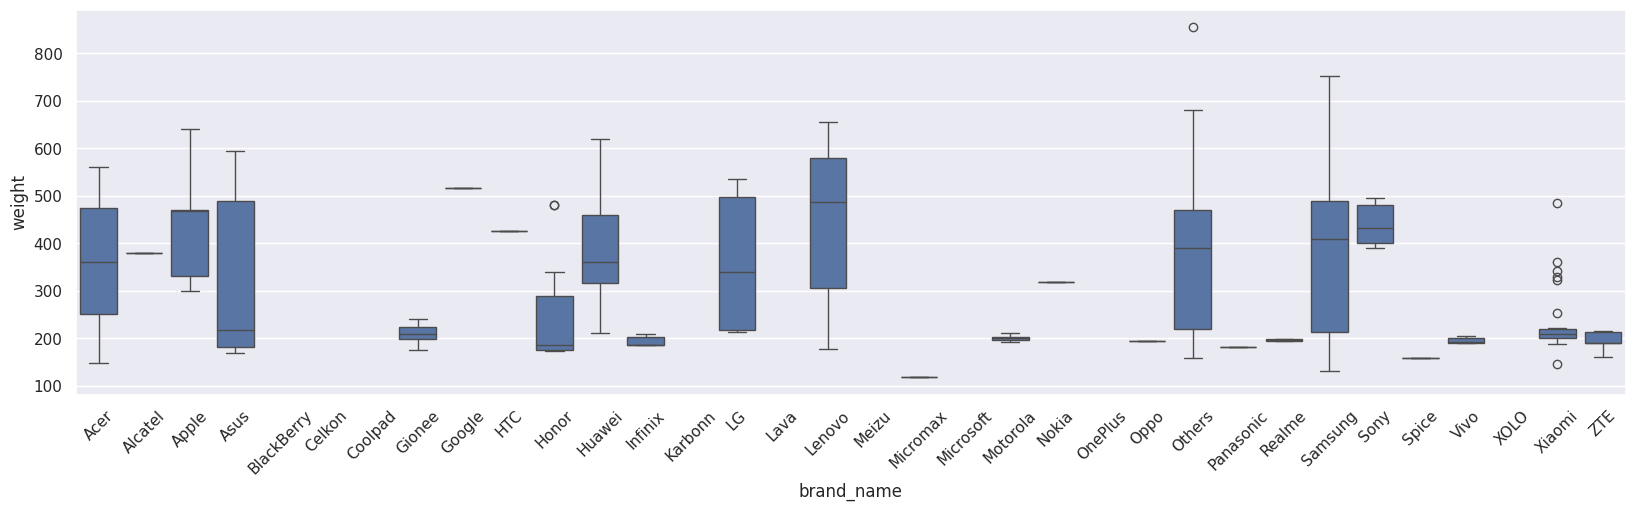

In [ ]:
threshold = 4500                                                                                                       #threshold for large batteries
plt.figure(figsize=(20,5))
sns.boxplot(x=large_battery_devices['brand_name'], y=large_battery_devices['weight'], order = brand_name_alphabetized) #boxplot of weight vs brand name for large battery devices
plt.xticks(rotation=45)
plt.show()


Observations:

- large battery Samsung devices vary the most on weight
- many brands offer devices with large batteries but relatively low weight
- Blackberry, Celkon, Coolpad, Karbonn, Lava, Meizu, Microsoft, OnePlus and Xolo do not offer devices with large batteries
- for many brands 75% of their devices weigh below 500 grams

### How many phones and tablets are available across different brands with a screen size larger than 6 inches?

In [ ]:
threshold = 15.24                                                                                    #6 inches = 15.24 cm
large_screen_devices = udd_with_missing_values[(udd_with_missing_values['screen_size'] > threshold)] #filter for devices with large screens

In [ ]:
large_screen_devices.shape

(1099, 15)

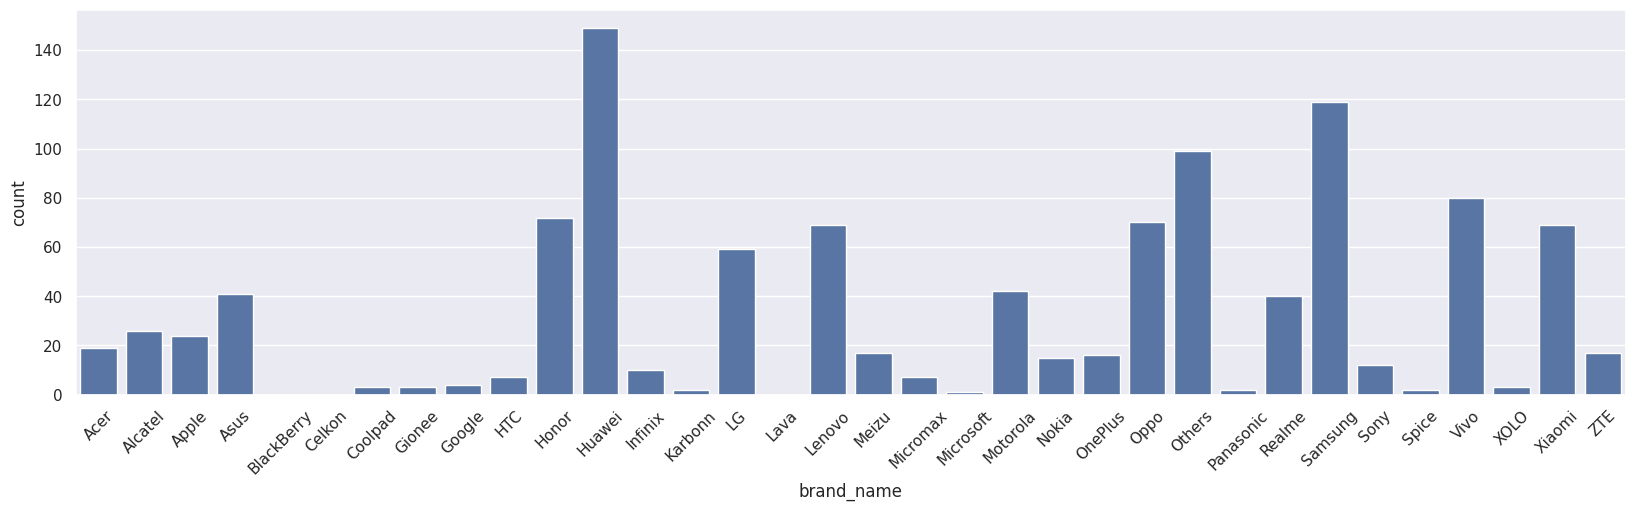

In [ ]:
plt.figure(figsize=(20,5))
sns.countplot(x=large_screen_devices['brand_name'], order = brand_name_alphabetized) #countplot of large screen devices by brand
plt.xticks(rotation=45)
plt.show()

Observations:

- 1099 devices across different brands are available with a screen size larger than 6 inches
- Huawei offers the most devices with a screen size larger than 6 inches, followed by Samsung
- BlackBerry, Celkon and Lava offer no devices with a screen size larger than 6 inches

### What is the distribution of devices offering greater than 8MP selfie cameras across brands?

In [ ]:
threshold = 8                                                                                               #threshold for high MP selfie cameras
high_mp_selfie_devices = udd_with_missing_values[(udd_with_missing_values['selfie_camera_mp'] > threshold)] #filter for devices with high MP selfie cameras

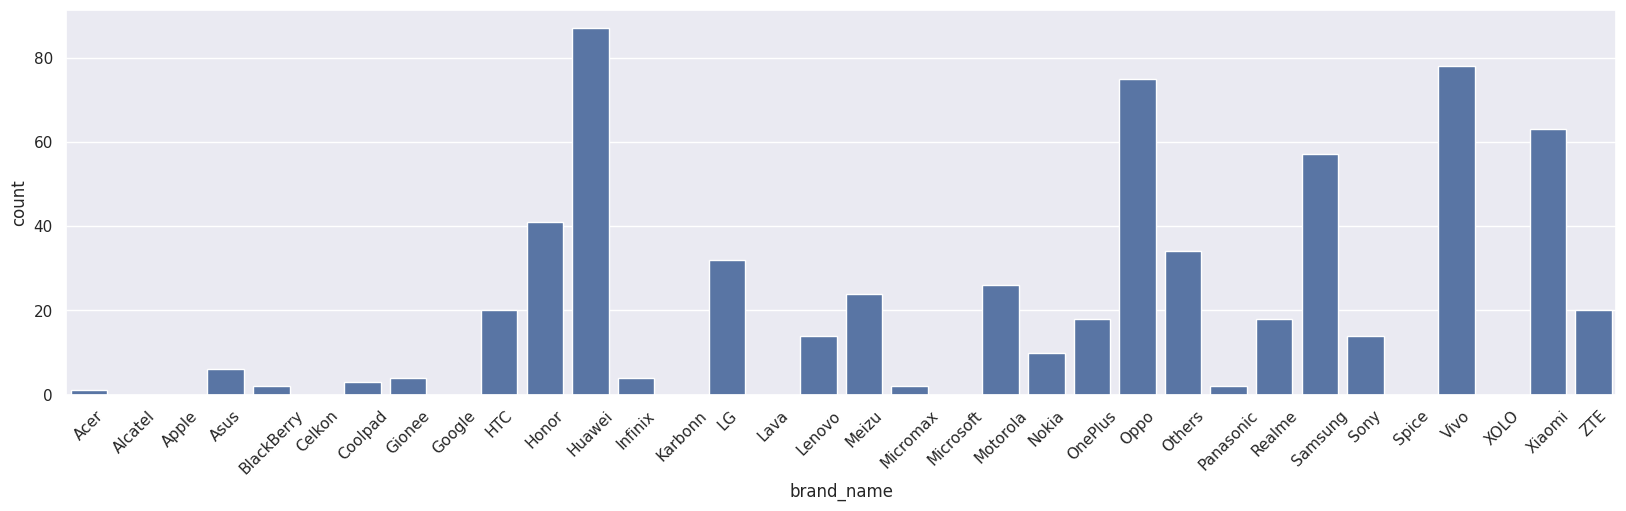

In [ ]:
plt.figure(figsize=(20,5))
sns.countplot(x=high_mp_selfie_devices['brand_name'], order = brand_name_alphabetized) #countplot of high MP selfie devices by brand
plt.xticks(rotation=45)
plt.show()

Observations:
- Huawei offers the most devices with a greater than 8MP selfie camera, followed by Vivo and Oppo
- Alcatel, Celkon, Google, Karbonn, Lava, Microsoft, Spice, and Xolo do not offer devices with a larger than 8MP selfie camera

### Which attributes are highly correlated with the normalized price of a used device?

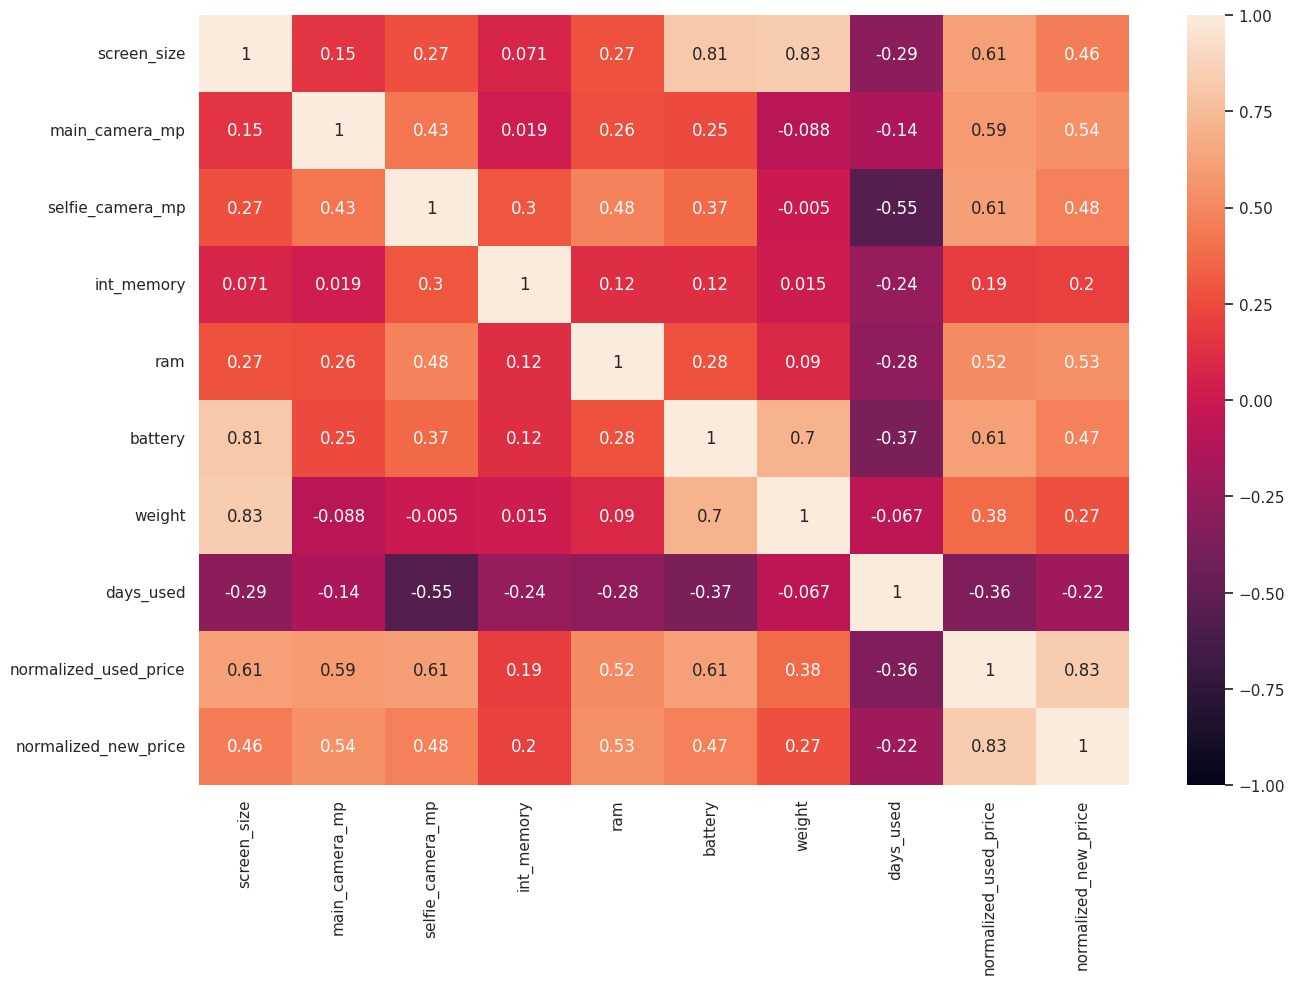

In [ ]:
plt.figure(figsize=(15,10))
heatmap_columns = udd_with_missing_values.select_dtypes(include=[np.number]).columns #list of numerical columns
heatmap_columns = heatmap_columns.drop('release_year')                               #dropping release year as this is more of a categorical variable
sns.heatmap(data=udd_with_missing_values[heatmap_columns].corr(), annot=True, vmin=-1, vmax=1);       #heatmap of numerical values


Observations:

- normalized used price is highly correlated with normalized new price, and is somewhat correlated (greater than .6) with battery, selfie camera mp and screen size, suggesting the new price of a phone has a high impact on the used price

- battery and weight are highly correlated with screen size suggesting that the larger the screen size, the battery and / or weight will similarly be larger

- the strongest negative correlation is between selfie camera mp and days used

## Data Preprocessing

- Missing value treatment
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

### Missing Value Treatment

In [ ]:
udd = UDD.copy() #making a copy of the dataset

<Axes: xlabel='main_camera_mp'>

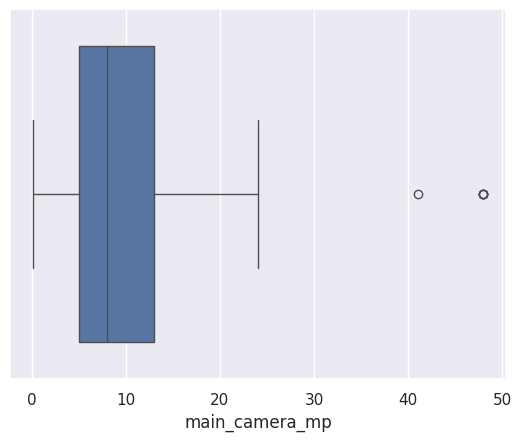

In [ ]:
sns.boxplot(x=udd['main_camera_mp']) #checking for outliers

In [ ]:
udd.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,179
selfie_camera_mp,2
int_memory,4
ram,4
battery,6


In [ ]:
median_main_camera_mp_by_year = udd.groupby(['release_year'])['main_camera_mp'].transform('median')              #group the main_camera_mp for each release year
median_selfie_camera_mp_by_year = udd.groupby(['release_year'])['selfie_camera_mp'].transform('median')          #group the selfie_camera_mp for each release year
median_int_memory_by_year = udd.groupby(['release_year'])['int_memory'].transform('median')                      #group the int_memory for each release year
median_ram_by_year = udd.groupby(['release_year'])['ram'].transform('median')                                    #group the ram for each release year
median_battery_by_year = udd.groupby(['release_year'])['battery'].transform('median')                            #group the battery for each release year
median_weight_by_year = udd.groupby(['release_year'])['weight'].transform('median')                              #group the weight for each release year

In [ ]:
udd['main_camera_mp'] = udd['main_camera_mp'].fillna(median_main_camera_mp_by_year)       # fill missing values in main_camera_mp with the median main_camera_mp for its respective release year
udd['selfie_camera_mp'] = udd['selfie_camera_mp'].fillna(median_selfie_camera_mp_by_year) # fill missing values in selfie_camera_mp with the median selfie_camera_mp for its respective release year
udd['int_memory'] =  udd['int_memory'].fillna(median_int_memory_by_year)                  # fill missing values in int_memory with the median int_memory for its respective release year
udd['ram'] = udd['ram'].fillna(median_ram_by_year)                                        # fill missing values in ram with the median ram for its respective release year
udd['battery'] = udd['battery'].fillna(median_battery_by_year)                            # fill missing values in battery with the median battery for its respective release year
udd['weight'] = udd['weight'].fillna(median_weight_by_year)                               # fill missing values in weight with the median weight for its respective release year

In [ ]:
udd.isnull().sum()

,0
brand_name,0
os,0
screen_size,0
4g,0
5g,0
main_camera_mp,0
selfie_camera_mp,0
int_memory,0
ram,0
battery,0


Observations:

- the existence of outliers suggests that using the median value is a better method than using the mean for imputing missing values

- we are making the assumption that the median value for missing values in each column can be used to replace missing values without significantly impacting the data

### Feature Engineering

In [ ]:
udd['phone_age'] = 2021 - udd['release_year'] #calculating the age of the phone

In [ ]:
udd.tail()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price,phone_age
3449,Asus,Android,15.34,yes,no,12.2,8.0,64.0,6.0,5000.0,190.0,2019,232,4.492337,6.483872,2
3450,Asus,Android,15.24,yes,no,13.0,8.0,128.0,8.0,4000.0,200.0,2018,541,5.037732,6.251538,3
3451,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,3.0,4000.0,165.0,2020,201,4.357350,4.528829,1
3452,Alcatel,Android,15.80,yes,no,13.0,5.0,32.0,2.0,4000.0,160.0,2020,149,4.349762,4.624188,1
3453,Alcatel,Android,12.83,yes,no,13.0,5.0,16.0,2.0,4000.0,168.0,2020,176,4.132122,4.279994,1


In [ ]:
udd['phone_age'].value_counts()

,count
phone_age,
7,642
8,570
6,515
2,446
5,383
3,322
4,299
1,277


In [ ]:
udd['phone_age'].describe()

,phone_age
count,3454.000000
mean,5.034742
std,2.298455
min,1.000000
25%,3.000000
50%,5.500000
75%,7.000000
max,8.000000


Observations:

- on average, the phones in this data set are 5 years old
- all used phones on this dataset are at least 1 year old, and 277 in this dataset are 1 year old
- the oldest phones in the dataset are 8 years old, of which ther are 570

### Outlier Detection

In [ ]:
udd_numerical = udd.select_dtypes(include=[np.number]) #selecting numerical columns

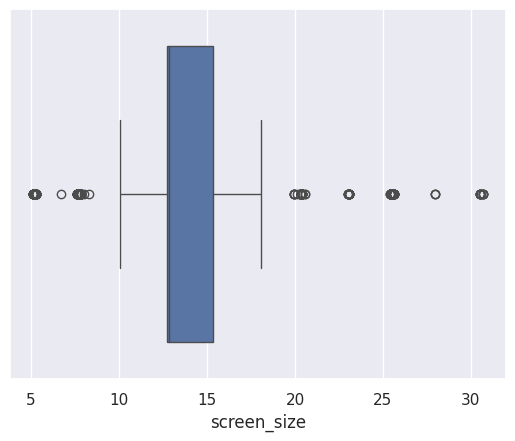

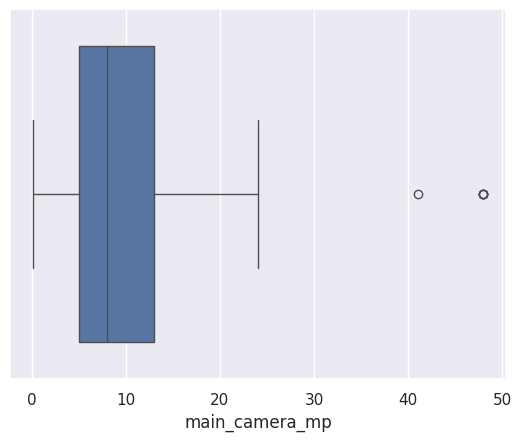

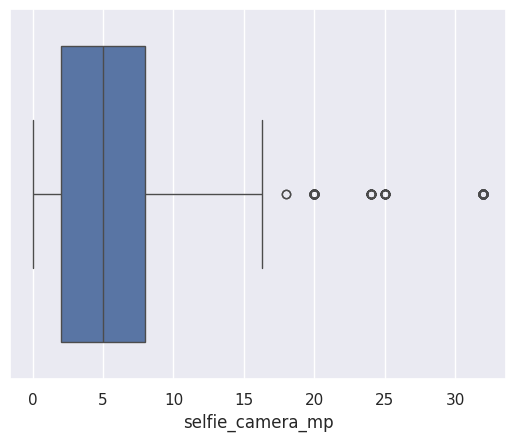

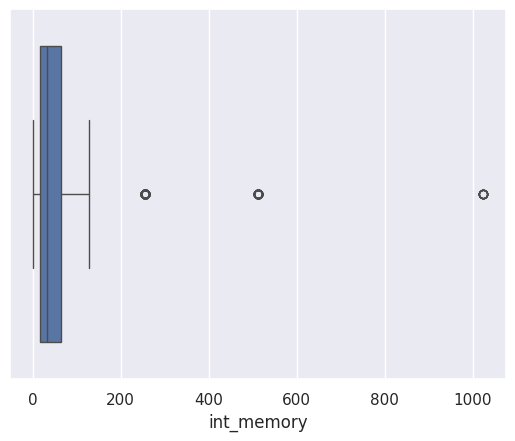

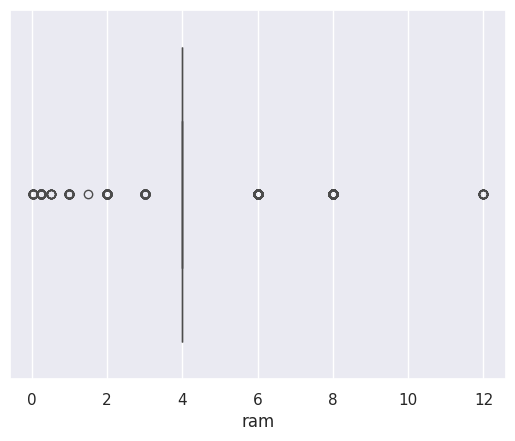

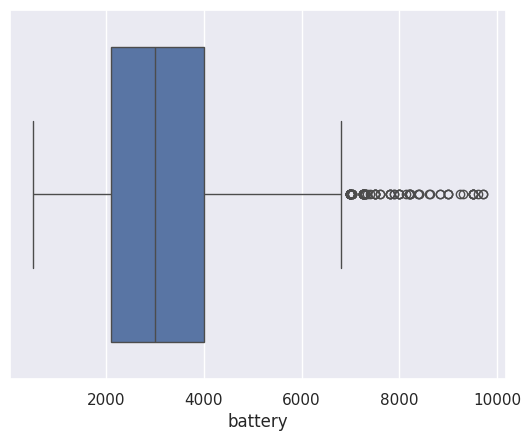

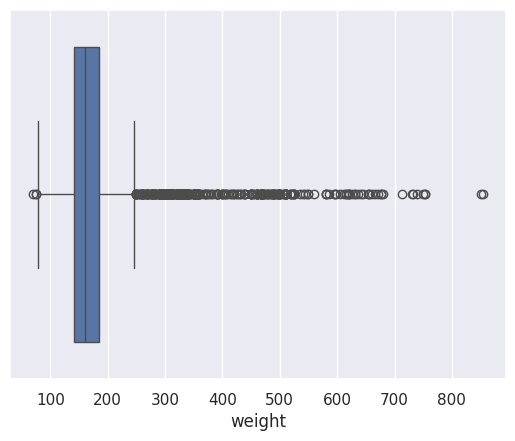

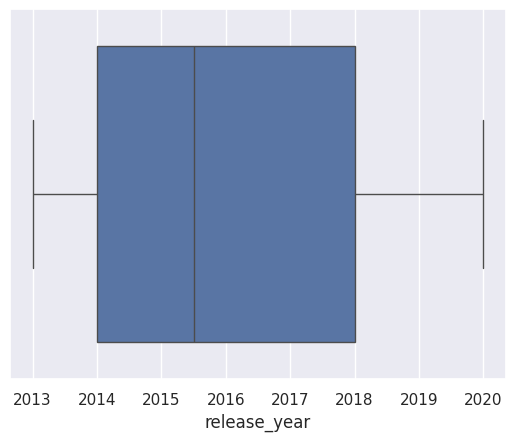

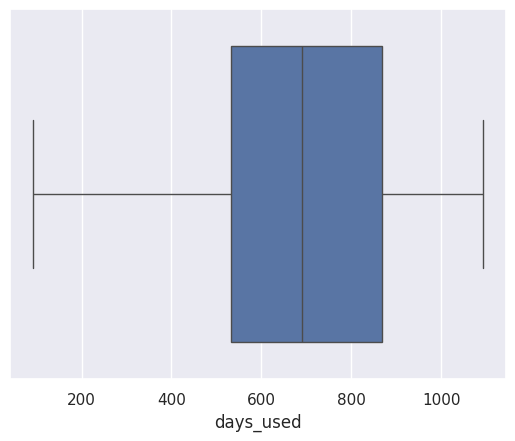

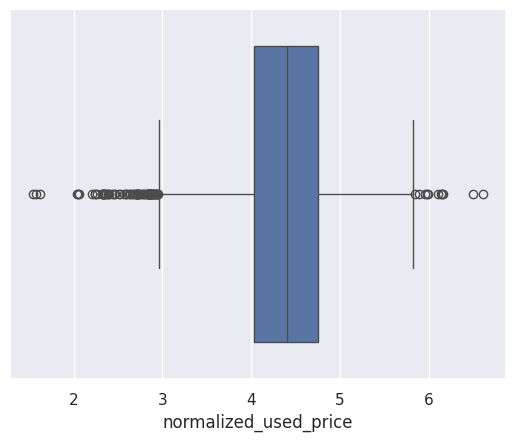

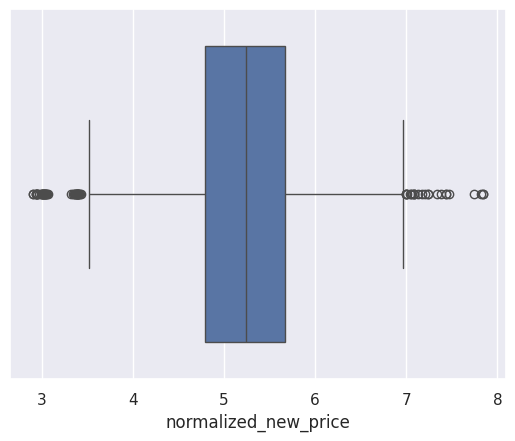

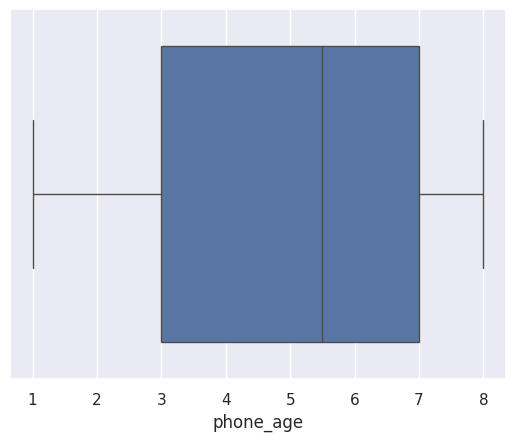

In [ ]:
for col in udd_numerical:
  sns.boxplot(x=udd[col])
  plt.show()

Observations:

- there are many outliers in the data
- no outliers appear to be data entry mistakes, therefore we will not remove them

### Preparing Data

In [ ]:
x = udd.drop(['normalized_used_price','release_year'], axis=1) #independent variables
y = udd['normalized_used_price']                #dependent variable

x.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,phone_age
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,1
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,1
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,1
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,1
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,1


In [ ]:
y.head()

,normalized_used_price
0,4.307572
1,5.162097
2,5.111084
3,5.135387
4,4.389995


In [ ]:
x = sm.add_constant(x) #adding a constant to the independent variables

In [ ]:
x = pd.get_dummies(x, columns=x.select_dtypes(include=["object", "category"]).columns.tolist(), drop_first=True)  # one hot encoding the categorical variables
x.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.715100,...,False,False,False,False,False,False,False,False,True,False
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.519018,...,False,False,False,False,False,False,False,False,True,True
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.884631,...,False,False,False,False,False,False,False,False,True,True
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.630961,...,False,False,False,False,False,False,False,False,True,True
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.947837,...,False,False,False,False,False,False,False,False,True,False


In [ ]:
x = x.astype(float) #converting the data type of the independent variables to float
x.head()

,const,screen_size,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_new_price,...,brand_name_Spice,brand_name_Vivo,brand_name_XOLO,brand_name_Xiaomi,brand_name_ZTE,os_Others,os_Windows,os_iOS,4g_yes,5g_yes
0,1.0,14.50,13.0,5.0,64.0,3.0,3020.0,146.0,127.0,4.715100,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,17.30,13.0,16.0,128.0,8.0,4300.0,213.0,325.0,5.519018,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,1.0,16.69,13.0,8.0,128.0,8.0,4200.0,213.0,162.0,5.884631,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
3,1.0,25.50,13.0,8.0,64.0,6.0,7250.0,480.0,345.0,5.630961,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,1.0,15.32,13.0,8.0,64.0,3.0,5000.0,185.0,293.0,4.947837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1) #splitting the data into train and test sets
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(2417, 49) (1037, 49) (2417,) (1037,)


Observations:

- there are 2417 rows in the training data
- there are 1037 rows in the test data
- both test and train data have 50 columns

## Exploratory Data Analysis (EDA)

- It is a good idea to explore the data once again after manipulating it.

### Brand Name

<Axes: xlabel='brand_name', ylabel='count'>

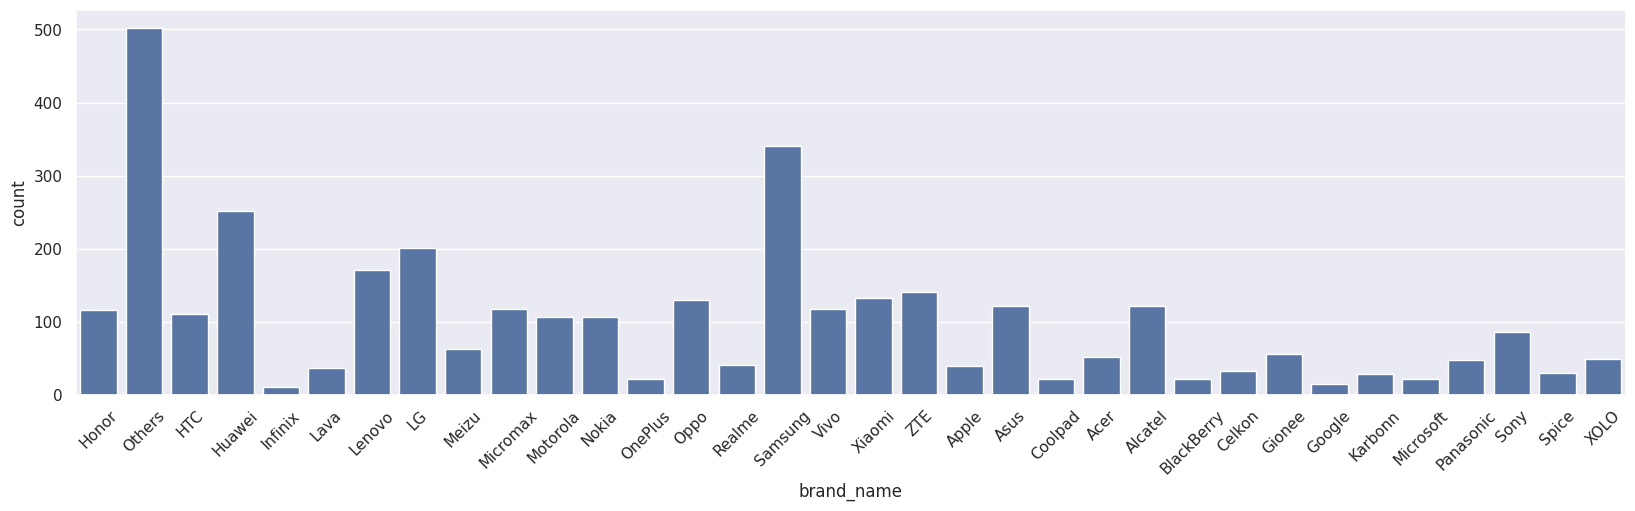

In [ ]:
plt.figure(figsize=(20,5))
plt.xticks(rotation=45)
sns.countplot(x=udd['brand_name'])

Observations:

- Samsung, Huawei and unnamed other brands are the most common brands in the dataset


### Screen Size

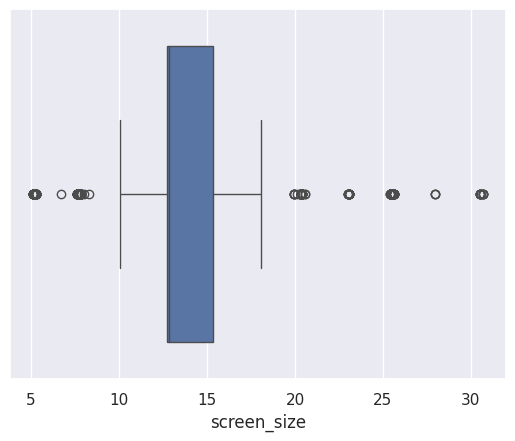

In [ ]:
sns.boxplot(x=udd['screen_size'])
plt.show()

Observations:

- There are many outliers in screensize, a possible explanation for this could be small numbers of flip phones and extra large tablets exist in the data

- Not accounting for outliers, ~100% of the screen sizes in the dataset lie between 10 cm and about 17 cm

### Main Camera Megapixels

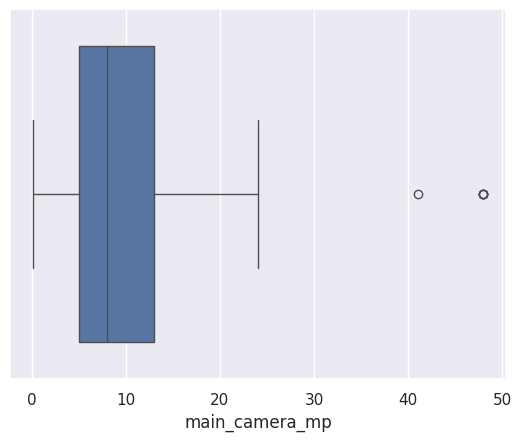

In [ ]:
sns.boxplot(x=udd_with_missing_values['main_camera_mp'])
plt.show()

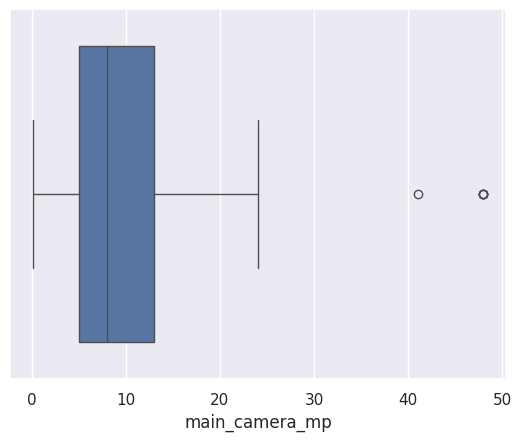

In [ ]:
sns.boxplot(x=udd['main_camera_mp'])
plt.show()

Observations:
- main camera mp had the most missing values in the original data
- the distribution of main camera mp has not changed significantly after processing the data and imputing missing variables
- 75% of the devices in the data set have between about 5mp and 25mp

### Selfie Camera Megapixels

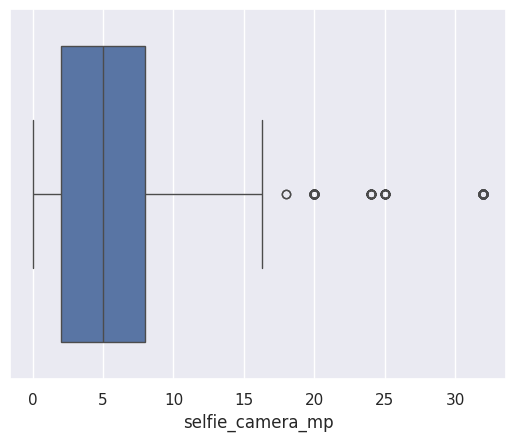

In [ ]:
sns.boxplot(x=udd_with_missing_values['selfie_camera_mp'])
plt.show()

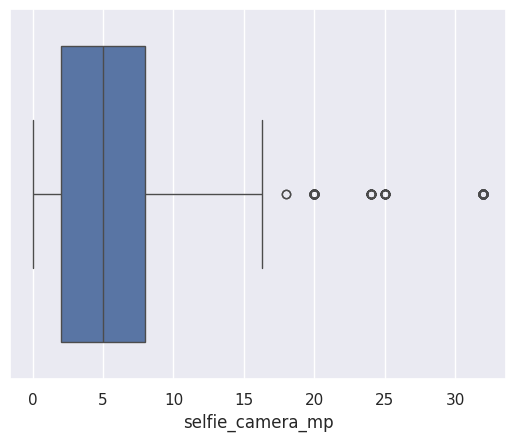

In [ ]:
sns.boxplot(x=udd['selfie_camera_mp'])
plt.show()

Observations:
- selfie camera mp had only 2 values missing in the original data
- the distribution of selfie camera mp has not changed discernably after processing the data and imputing missing variables
- about 75% of the devices in the dataset have between about 2mp to 16mp selfie cameras
- selfie cameras tend to be lower in resolution than main cameras for devices in this dataset

### Internal Memory

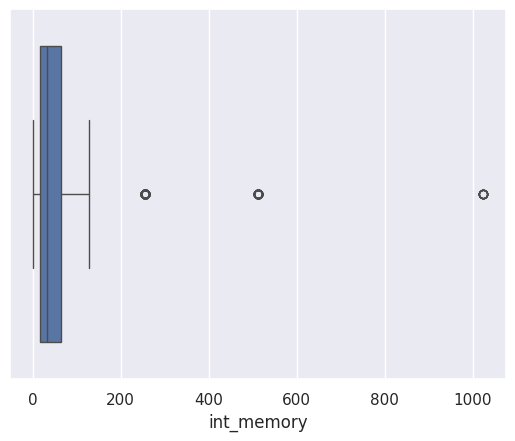

In [ ]:
sns.boxplot(x=udd_with_missing_values['int_memory']) #boxplot of internal memory from original dataset
plt.show()

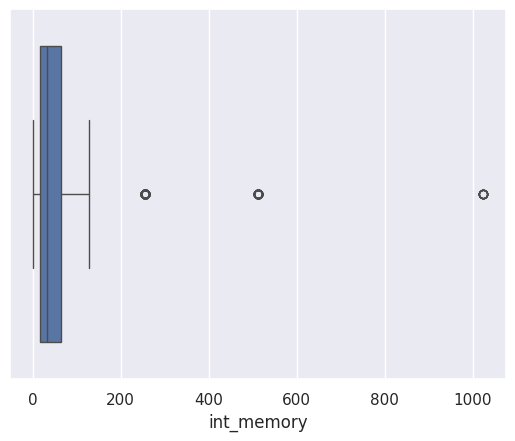

In [ ]:
sns.boxplot(x=udd['int_memory']) #boxplot of internal memory from processed dataset
plt.show()

Observations:
- internal memory had only 4 values missing in the original data
- the distribution of internal memory has not changed discernably after processing the data and imputing missing variables
- not including outliers, nearly 100% of the devices in the dataset have less than 200 gb of memory

### Ram

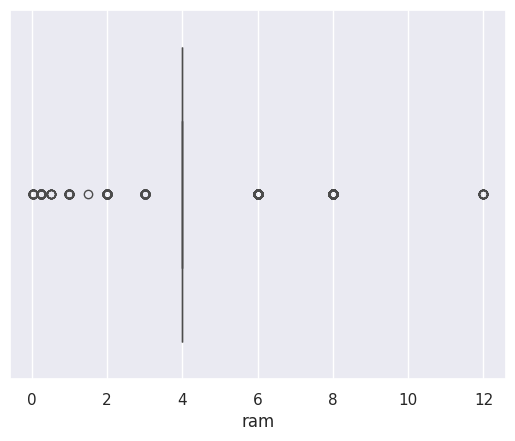

In [ ]:
sns.boxplot(x=udd_with_missing_values['ram']) #box plot of ram from original dataset
plt.show()

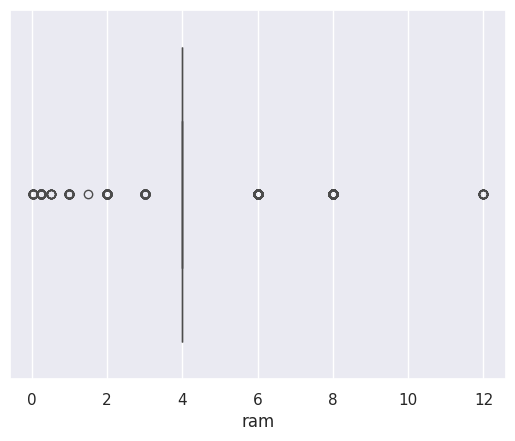

In [ ]:
sns.boxplot(x=udd['ram']) #boxplot of ram from processed data set
plt.show()

Observations:
- Ram had only 4 values missing in the original data
- the distribution of Ram has not changed discernably after processing the data and imputing missing variables
- not including outliers, nearly 100% of used devices in this data have 4gb of ram

### Battery

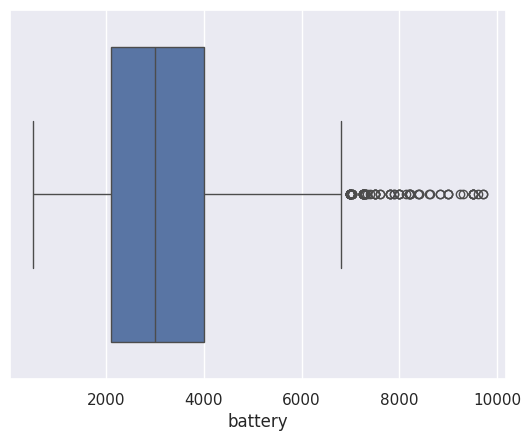

In [ ]:
sns.boxplot(x=udd_with_missing_values['battery']) #boxplot of battery from original dataset
plt.show()

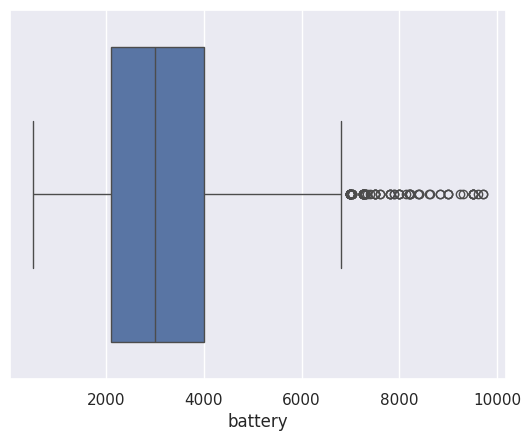

In [ ]:
sns.boxplot(x=udd['battery']) #boxplot of battery from processed dataset
plt.show()

Observations:
- battery had only 6 values missing in the original data
- the distribution of battery has not changed discernably after processing the data and imputing missing variables
- 50% of devices in the dataset have between 2000 and 4000 mAh of capacity
- less than 25% of the devices in the dataset have 'large' batteries as defined above

### Weight

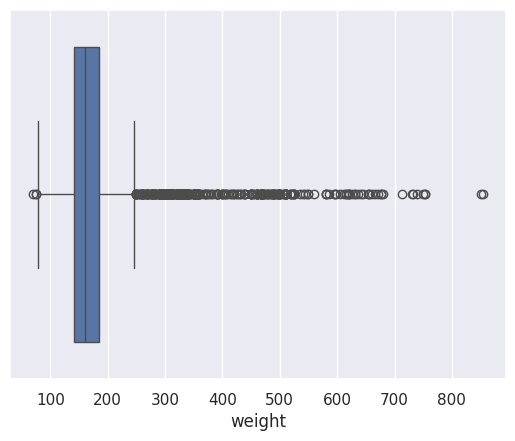

In [ ]:
sns.boxplot(x=udd_with_missing_values['weight']) #boxplot of weight from original dataset
plt.show()

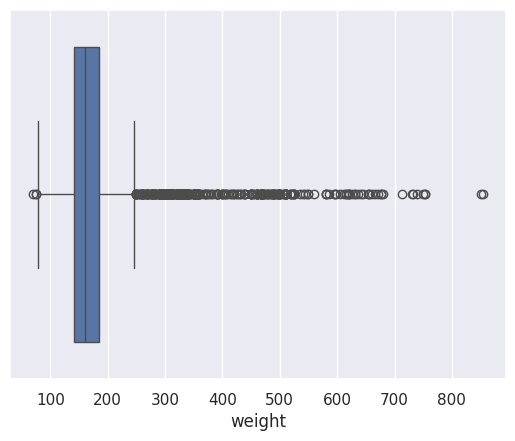

In [ ]:
sns.boxplot(x=udd['weight']) #boxplot of weight from the processed dataset
plt.show()

Observations:
- weight had only 7 values missing in the original data
- the distribution of weight has not changed discernably after processing the data and imputing missing variables
- Weight has a lot of outliers on the larger end of the distribution.
- most of the used devices in the dataset weigh between about 90 to 250 grams

### Phone Age

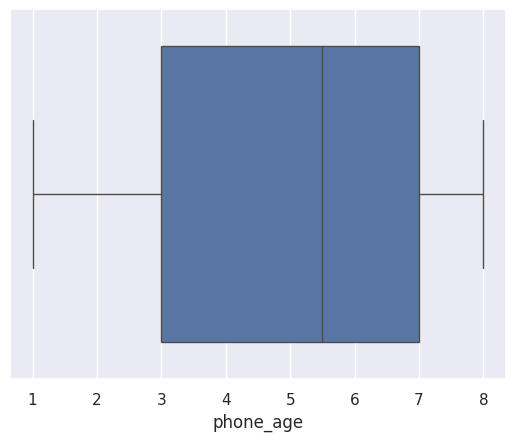

In [ ]:
sns.boxplot(x=udd['phone_age'])
plt.show()

Observations:

- phones range from 1 to 8 years old in the dataset, with 50% of the used devices being 3-7 years old

### Days Used

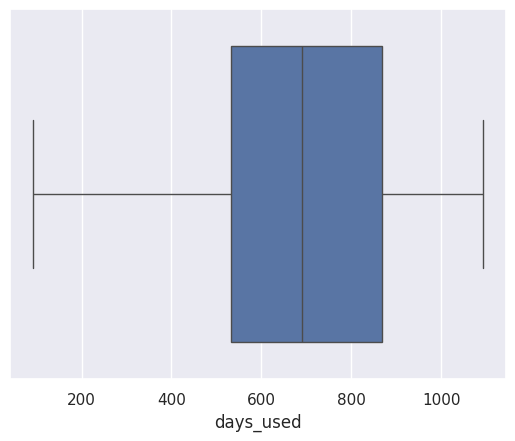

In [ ]:
sns.boxplot(x=udd['days_used'])
plt.show()

Observations:
- 50% of the devices in the dataset have been used between about 550 and 850 dayus

## Multivariate analysis

### Normalized New Price and Normalize Used Price

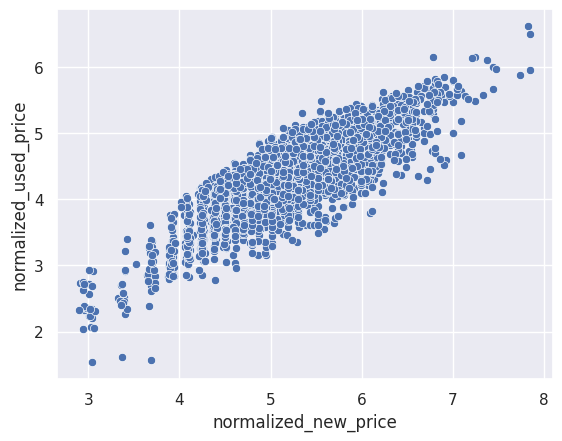

In [ ]:
sns.scatterplot(x=udd['normalized_new_price'], y=udd['normalized_used_price'])
plt.show()

Observations:

- there seems to be a linear relationship between normalized used price and normalized new price

### Normalized used price and phone age

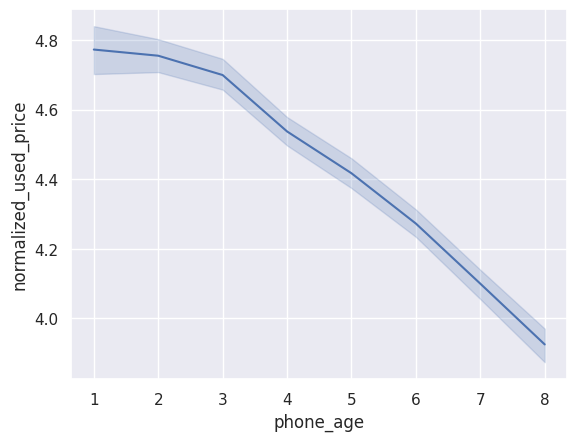

In [ ]:
sns.lineplot(x=udd['phone_age'], y=udd['normalized_used_price'])
plt.show()

Observations:

- Normalized used price seems to decline gradually for the first 3 years of a phones age, and then decrease more sharply after 3 years

## Heatmap


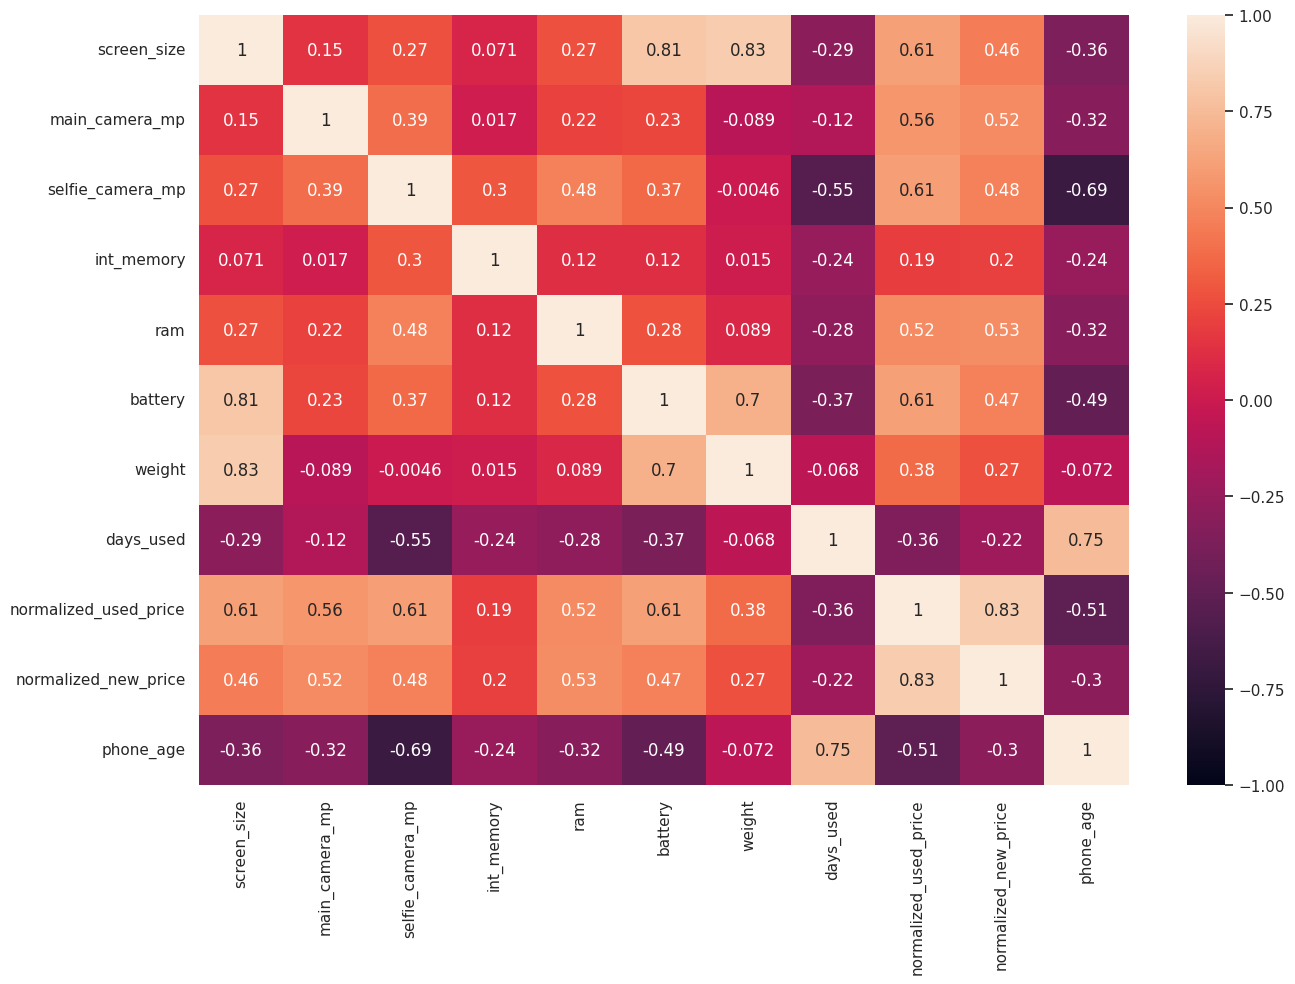

In [ ]:
plt.figure(figsize=(15,10))
heatmap_columns = udd.select_dtypes(include=[np.number]).columns                  #list of numerical columns
heatmap_columns = heatmap_columns.drop('release_year')                            #dropping release year as this is more of a categorical variable
sns.heatmap(data=udd[heatmap_columns].corr(), annot=True, vmin=-1, vmax=1);       #heatmap of numerical values


Observations:

- The strongest positive correlations exist between battery and weight and screen size
- the strongest negative correlations exist between selfie camera mp and phone age, and between days used and selfie camera mp, suggesting newer phones tend to have higher selfie camera mp and the mp of selfie cameras is more strongly affected by phone age than main camera mp.

## Model Building - Linear Regression

In [ ]:
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.845
Model:                               OLS   Adj. R-squared:                  0.841
Method:                    Least Squares   F-statistic:                     268.1
Date:                   Thu, 20 Mar 2025   Prob (F-statistic):               0.00
Time:                           18:27:53   Log-Likelihood:                 121.53
No. Observations:                   2417   AIC:                            -145.1
Df Residuals:                       2368   BIC:                             138.7
Df Model:                             48                                         
Covariance Type:               nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------


Observations:

- R-squared and Adjusted R squared can explain 84.5% and 84.1% of the variance in normalized used price of devices

- the model is not underfitting the data

## Model Performance Check

In [ ]:
def adj_r2_score(predictors, targets, predictions):                # function for finding adjusted R squared
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


def mape_score(targets, predictions):                               #function for finding MAPE
    return np.mean(np.abs(targets - predictions) / targets) * 100

def model_performance_regression(model, predictors, target):        #function for finding values to check model performance

    pred = model.predict(predictors)                                # predicting using the independent variables

    r2 = r2_score(target, pred)                                     # find R-squared
    adjr2 = adj_r2_score(predictors, target, pred)                  # find djusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))                # find MSE
    mae = mean_absolute_error(target, pred)                         # find MAE
    mape = mape_score(target, pred)                                 # find MAPE

    df_perf = pd.DataFrame({"RMSE": rmse,"MAE": mae,"R-squared": r2,"Adj. R-squared": adjr2,"MAPE": mape,},index=[0],) #creating a dataframe of the metrics

    return df_perf


In [ ]:
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, x_train, y_train) # checking model performance on train set (seen 70% data)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.230105,0.180571,0.844587,0.84137,4.332694


In [ ]:
print("Test Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, x_test, y_test) # checking model performance on test set (seen 30% data)
olsmodel_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.239083,0.185073,0.841519,0.833651,4.511746


Observations:

- the R2 is .84 for the training data, so the model is not underfitting
- the RMSE and MAE of the training and test data are very close, so the model is not overfitting
- MAPE value of 4.5 on the test data suggests that the model is able to predict within 4.5% error of the normalized used phone price

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

We will be checking the following Linear Regression assumptions:

1. No Multicollinearity

2. Linearity of variables

3. Independence of error terms

4. Normality of error terms

5. No Heteroscedasticity



TEST FOR MULTICOLLINEARITY:

Multicollinearity occurs when predictor variables in a regression model are correlated. This correlation is a problem because predictor variables should be independent. If the correlation between variables is high, it can cause problems when we fit the model and interpret the results. When we have multicollinearity in the linear model, the coefficients that the model suggests are unreliable.

There are different ways of detecting (or testing) multicollinearity. One such way is by using the Variance Inflation Factor, or VIF.

Variance Inflation Factor (VIF): Variance inflation factors measure the inflation in the variances of the regression parameter estimates due to collinearities that exist among the predictors. It is a measure of how much the variance of the estimated regression coefficient  βk  is "inflated" by the existence of correlation among the predictor variables in the model.

- If VIF is 1, then there is no correlation among the  k th predictor and the remaining predictor variables, and hence, the variance of  βk  is not inflated at all.
General Rule of thumb:

- If VIF is between 1 and 5, then there is low multicollinearity.
- If VIF is between 5 and 10, we say there is moderate multicollinearity.
- If VIF is exceeding 10, it shows signs of high multicollinearity.

### Multicollinearity

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def find_vif(predictors, exclude_prefixes=['brand_name','os']):
  if exclude_prefixes:
    columns_to_include = [col for col in predictors.columns if not any(col.startswith(prefix) for prefix in exclude_prefixes)] #exclude dummy variables by checking column names
    predictors = predictors[columns_to_include]
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    vif["VIF"] = [variance_inflation_factor(predictors.values, i)for i in range(len(predictors.columns))]                       #calculating VIF for each variable

    return vif

In [ ]:
find_vif(x_train)

,feature,VIF
0,const,100.799269
1,screen_size,6.153566
2,main_camera_mp,1.951015
3,selfie_camera_mp,2.541265
4,int_memory,1.246398
5,ram,1.981963
6,battery,3.774554
7,weight,5.576557
8,days_used,2.570155
9,normalized_new_price,2.542490


Observations:

- We will be ignoring the VIF for dummy variables
- The variables showing multicolinearity greater than 5 are screen size and weight. These variables show moderate multicollinearity.
  - this follows logically with the correlation we saw on our heatmap in EDA

To remove multicollinearity

- Drop every column one by one that has a VIF score greater than 5.
- Look at the adjusted R-squared and RMSE of all these models.
- Drop the variable that makes the least change in adjusted R-squared.
- Check the VIF scores again.
- Continue till you get all VIF scores under 5.

In [ ]:
def treating_multicollinearity(predictors, target, high_vif_columns):

    adj_r2 = []                                                                 # empty lists to store adj. R-squared and RMSE values
    rmse = []

    for cols in high_vif_columns:                                               # iterating through the high VIF columns
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]
        olsmodel = sm.OLS(target, train).fit()
        adj_r2.append(olsmodel.rsquared_adj)                                    # appending adj. R-squared and RMSE values to their respective lists
        rmse.append(np.sqrt(olsmodel.mse_resid))

    temp = pd.DataFrame({"col": high_vif_columns,"Adj. R-squared after_drop col": adj_r2,"RMSE after drop col": rmse,}).sort_values(by="Adj. R-squared after_drop col", ascending=False) #creating a dataframe for the results
    temp.reset_index(drop=True, inplace=True)

    return temp

In [ ]:
moderate_vif_col_list = ['screen size','weight'] #creating a list of the columns with a moderate vif

treated = treating_multicollinearity(x_train, y_train, moderate_vif_col_list)
treated

,col,Adj. R-squared after_drop col,RMSE after drop col
0,screen size,0.841437,0.232474
1,weight,0.837839,0.235096


In [ ]:
x_train2 = x_train.loc[:, x_train.columns != 'screen_size'] #x train column without screen size
x_test2 = x_test.loc[:, x_test.columns != 'screen_size']    #x test column without screen size

vif= find_vif(x_train2)
vif

,feature,VIF
0,const,91.896213
1,main_camera_mp,1.934094
2,selfie_camera_mp,2.539824
3,int_memory,1.244831
4,ram,1.956491
5,battery,3.537035
6,weight,2.824598
7,days_used,2.565346
8,normalized_new_price,2.495487
9,phone_age,4.445059


Observations:

- we have resolved problematic multicollinearity in the data as no values have a VIF > 5

###Dealing with high p-value variables


- Some of the dummy variables in the data have p-value > 0.05. So, they are not significant and we'll drop them
- Sometimes p-values change after dropping a variable. So, we'll not drop all variables at once
- Instead, we will do the following:
  - Build a model, check the p-values of the variables, and drop the column with the highest p-value
  - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value
  - Repeat the above two steps till there are no columns with p-value > 0.05

In [ ]:

predictors = x_train2.copy()                    #copying x_train2
udd_cols = predictors.columns.tolist()

max_p_value = 1                                 # setting an initial max p-value

while len(udd_cols) > 0:                        # iterating through the columns
    x_train_aux = predictors[udd_cols]          # defining the train set
    model = sm.OLS(y_train, x_train_aux).fit()  # fitting the model

    p_values = model.pvalues                    # getting the p-values and the maximum p-value
    max_p_value = max(p_values)

    feature_with_p_max = p_values.idxmax()      # name of the variable with maximum p-value

    if max_p_value > 0.05:
        udd_cols.remove(feature_with_p_max)
    else:
        break
low_P_val_cols = udd_cols
print(low_P_val_cols)

['const', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'weight', 'normalized_new_price', 'phone_age', 'brand_name_Others', 'brand_name_Samsung', 'brand_name_Sony', 'brand_name_Xiaomi', 'os_Others', 'os_iOS', '4g_yes']


In [ ]:
x_train3 = x_train2[low_P_val_cols]
x_test3 = x_test2[low_P_val_cols]

olsmod2 = sm.OLS(y_train, x_train3).fit()
print(olsmod2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     963.0
Date:                   Thu, 20 Mar 2025   Prob (F-statistic):               0.00
Time:                           18:27:56   Log-Likelihood:                 78.551
No. Observations:                   2417   AIC:                            -129.1
Df Residuals:                       2403   BIC:                            -48.04
Df Model:                             13                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [ ]:
print("Training Performance\n")                                               # checking model performance on train set (seen 70% data)
olsmod2_train_perf = model_performance_regression(olsmod2, x_train3, y_train)
olsmod2_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.234233,0.183132,0.838961,0.838022,4.402623


In [ ]:
print("Test Performance\n")                                                    # checking model performance on test set (seen 30% data)
olsmod2_test_perf = model_performance_regression(olsmod2, x_test3, y_test)
olsmod2_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.24109,0.18629,0.838847,0.83664,4.547497


Observations:

- Dropping variables with high p values has not made the model perform worse
- These values are very close to the first performance on train and test data

### Linearity and Independence

- We will test for linearity and independence by plotting fitted values vs residuals and look for patterns in the data with the following conclusions
  - no pattern: model is linear and residuals are independent
  - discernable pattern: model is non-linear and residuals are not independent


In [ ]:
udd_pred = pd.DataFrame() #creating a new dataframe

udd_pred["Actual Values"] = y_train                # actual values
udd_pred["Fitted Values"] = olsmod2.fittedvalues   # predicted values
udd_pred["Residuals"] = olsmod2.resid              # residuals

udd_pred.head()

,Actual Values,Fitted Values,Residuals
3026,4.087488,3.877460,0.210027
1525,4.448399,4.607293,-0.158894
1128,4.315353,4.296823,0.018529
3003,4.282068,4.244393,0.037675
2907,4.456438,4.466561,-0.010123


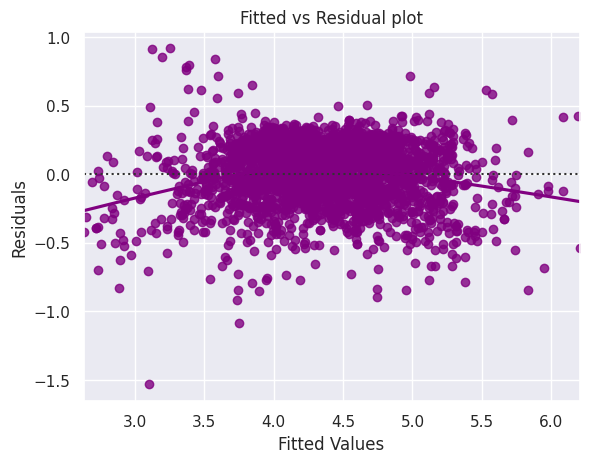

In [ ]:
sns.residplot(data=udd_pred, x="Fitted Values", y="Residuals", color="purple", lowess=True)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

Observations:

- there is no discernable pattern to the data above, therefore the assumptions of linearity and independence are satisfied


### Test for Normality

- The test for normality can be conduicted by checking the shape of the distribution of residuals, using a Q-Q plot of residuals, and using a Shapiro-Wilk test
- We are looking for a normal distribution plot for the residuals, a straight line for the Q-Q plot, and a P-value of greater than .05 for the Shapiro-Wilk test

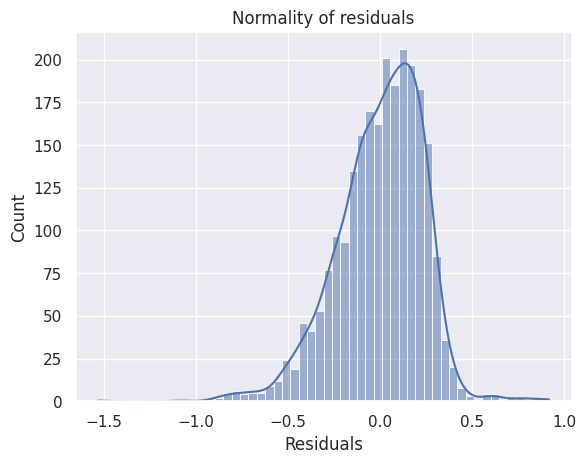

In [ ]:
sns.histplot(data=udd_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

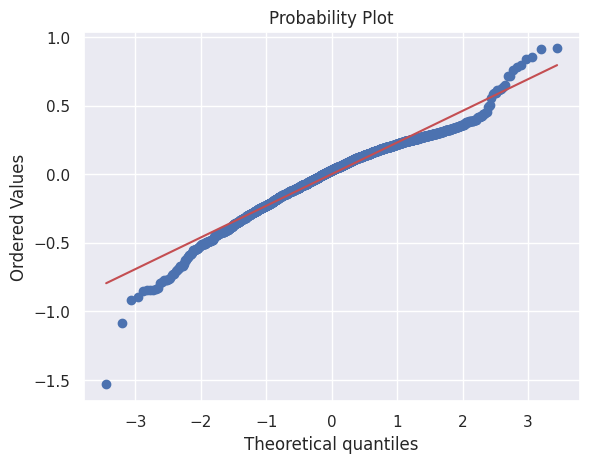

In [ ]:
import pylab
import scipy.stats as stats

stats.probplot(udd_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

In [ ]:
stats.shapiro(udd_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9688015327822114), pvalue=np.float64(1.6800225167831553e-22))

Observations:

- there is a bell shape to the residuals plot, but it is not perfectly normal
- the tails of the residuals are strictly non-normal, but follow a straight line closer to the middle
-the p-value is less than .05, so the residuals are not normal

- overall, the residuals are not perfectly normal, but they can be approxmiated to be normal

### Homoscedasticity

- The test for homoscedasticity is done with the goldfeldquandt test
- a P value greater than .05 means the residuals are homoscedastic

In [ ]:
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
test = sms.het_goldfeldquandt(udd_pred["Residuals"], x_train3)
lzip(name, test)

[('F statistic', np.float64(1.0092547146589539)),
 ('p-value', np.float64(0.4367683961009502))]

Observations:

- with a p value greater than .05, we can say the residuals are homoscedastic

## Final Model

In [ ]:
x_train_final = x_train3.copy()
x_test_final = x_test3.copy()

In [ ]:
olsmodel_final = sm.OLS(y_train, x_train_final).fit()
print(olsmodel_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.839
Model:                               OLS   Adj. R-squared:                  0.838
Method:                    Least Squares   F-statistic:                     963.0
Date:                   Thu, 20 Mar 2025   Prob (F-statistic):               0.00
Time:                           18:28:01   Log-Likelihood:                 78.551
No. Observations:                   2417   AIC:                            -129.1
Df Residuals:                       2403   BIC:                            -48.04
Df Model:                             13                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [ ]:
print("Training Performance\n")
olsmodel_final_train_perf = model_performance_regression(olsmodel_final, x_train_final, y_train) # checking model performance on train set (seen 70% data)
olsmodel_final_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.234233,0.183132,0.838961,0.838022,4.402623


In [ ]:
print("Test Performance\n")
olsmodel_final_test_perf = model_performance_regression(olsmodel_final, x_test_final, y_test) # checking model performance on test set (seen 30% data)
olsmodel_final_test_perf

Test Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.24109,0.18629,0.838847,0.83664,4.547497


Observations:

- this model is able to explain ~83% of the variation in the data
- the train and test RMSE and MAE are low and comparable, so our model is not suffering from overfitting
- The MAPE suggests we can predict within 4.5% of the normalized used price of a device
- the most significant variables for predicting normalized used price are:
  - main camera mp
  - selfie camera mp
  - ram
  - weight
  - normalized new price of the same device
  - phone age
  - 4g capability (and likely 5g too)

## Actionable Insights and Recommendations

- ReCell should use this model to help determine the normalized used price they should use for their phones

- ReCell should incentivize users to sell used devices that are not that old, and have higher camera mp, and are expensive when purchased new

- ReCell could focus on different segments of users that value high ram and care about the weight of the phone they are buying

- ReCell could offer some promotions to encourage consumers looking to buy a new phone to sell their phone to ReCell. This will possibly allow ReCell to gain more devices for resale.

- ReCell should try to gather additional data for analysis usch as customer demographics to help determine if focusing on consumers or businesses looking to buy used phones presents the greatest opportunity


___